In [2]:
import requests
from bs4 import BeautifulSoup

url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


In [3]:
soup = BeautifulSoup(response.text, "html.parser")

In [4]:
books = soup.find_all("article", class_="product_pod")

print(len(books))

20


In [5]:
print(books[0].prettify())

<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   Â£51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



In [6]:
book = books[0]

title = book.h3.a["title"]

print(title)

A Light in the Attic


In [7]:
price = book.find("p", class_="price_color").text

print(price)

Â£51.77


In [8]:
rating = book.find("p")["class"]

print(rating)

['star-rating', 'Three']


In [9]:
rating = book.find("p")["class"][1]

print(rating)

Three


In [10]:
titles = []
prices = []
ratings = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p")["class"][1]

    titles.append(title)
    prices.append(price)
    ratings.append(rating)

In [11]:
import pandas as pd

df = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Rating": ratings
})

df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [12]:
df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [13]:
df.shape

(20, 3)

In [14]:
df.describe().T

,count,unique,top,freq
Title,20,20,A Light in the Attic,1
Price,20,20,Â£51.77,1
Rating,20,5,One,6


In [15]:
df.columns

Index(['Title', 'Price', 'Rating'], dtype='str')

In [16]:
df.isnull().sum()

Title     0
Price     0
Rating    0
dtype: int64

In [17]:
df.dtypes

Title     str
Price     str
Rating    str
dtype: object

In [30]:
df["Price"] = (df["Price"].astype(str).str.replace(r"[^0-9.]", "",regex=True))

df["Price"] = pd.to_numeric(df["Price"],errors="coerce")

In [31]:
print(df["Price"].dtype)

float64


In [34]:
rating_map =  {
    
    "One":1,
    "Three":3,
    "Four":4,
    "Five":5
}

df["Rating"] = df["Rating"].map(rating_map)

In [35]:
df["Price"].max()

np.float64(57.25)

In [36]:
df["Price"].min()


np.float64(13.99)

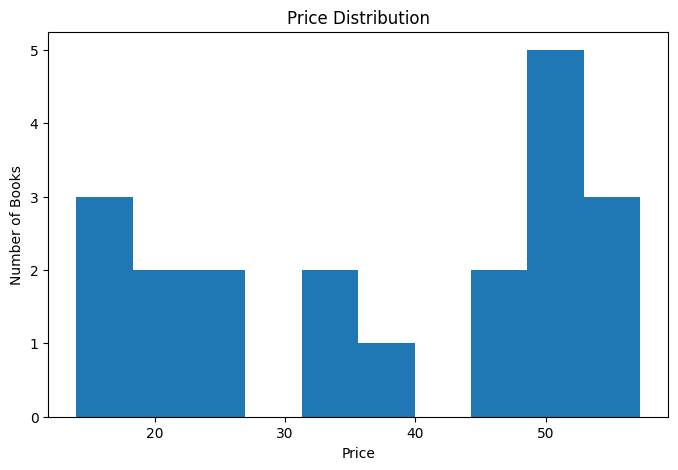

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.show()

In [44]:
df["Rating"].value_counts()

Series([], Name: count, dtype: int64)

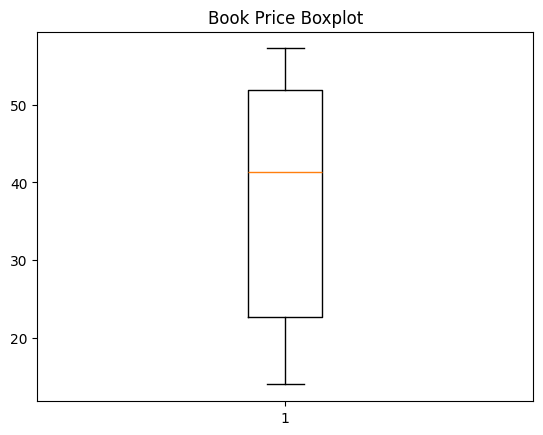

In [48]:
plt.boxplot(df["Price"])
plt.title("Book Price Boxplot")
plt.show()